In [26]:
import h5py
import numpy as np
import os #for change directory
import os.path
import scipy.io as sio #for read/write matlab file
from numpy import *
import time
import scipy.ndimage
import glob
import sys
import csv
import time
from PIL import Image
import matplotlib.pyplot as plt
from natsort import natsorted

from readMDA import *


In [27]:
def read_tiff_files_with_glob(folder_path):
    # Use glob to find all TIFF files in the folder
    tiff_files = natsorted(glob.glob(os.path.join(folder_path, '*.tif')))
    
    # Read each TIFF file and store it in a list
    images = [np.array(Image.open(tiff_file)) for tiff_file in tiff_files]
    
    # Stack the list of images into a 3D numpy array
    image_stack = np.stack(images, axis=0)
    
    return image_stack

In [ ]:
# data_dir = '/mnt/data2/ssrf17u/test/IC_1_large/'
# data_dir = '/mnt/data2/ssrf17u/test/Target_1_small_0_2s/'

# data_dir = '/mnt/data2/ssrf17u_20251026/IC_FIB/test_47degree/'
data_dir = '/mnt/data2/ssrf17u_20251026/test_target_stararea/test6_50nmstar/'


result_dir = data_dir+'results/scan001/'

if not os.path.exists(result_dir): os.makedirs(result_dir)


In [29]:
# read mda position file
# userdata_dir = '/mnt/data2/ssrf17u/test/Target_4_small_0_2s/Target_/'
# mda_name = userdata_dir+'Pos_0011.mda'
# userdata_dir = '/mnt/data2/ssrf17u/test/Target_3_small_0_2s/Target_3/'
# mda_name = userdata_dir+'Pos_0010.mda'
# userdata_dir = '/mnt/data2/ssrf17u/test/Target_1_small_0_2s/Target/'
# mda_name = userdata_dir+'Pos_0007' # for target1
# mda_name = userdata_dir+'Pos_0009' # for target2

userdata_dir = data_dir
mda_name = userdata_dir+'posi/Posi_0006.mda' # for IC1
# mda_name = userdata_dir+'pos_0011' # for IC2

print(mda_name)

# mda_data=readMDA(mda_name)

/mnt/data2/ssrf17u_20251026/test_target_stararea/test6_50nmstarposi/Posi_0006.mda


In [30]:
det_Npixel = 512
roi = '0_Ndp' + str(det_Npixel)

In [31]:
print("Creating geometry")
energy = 8.5
det_sample_dist = 2.4
det_pixel_size = 75e-6

lam = 1.23984193e-9/energy
dx = lam*det_sample_dist/det_pixel_size/det_Npixel #pixel size
print("real-space pixel size: " + str(dx))
print("wavelength: " + str(lam))

Creating geometry
real-space pixel size: 9.116484779411765e-09
wavelength: 1.4586375647058824e-10


In [33]:
# scan parameters
scan_stepsize_x = 200e-9 #in meter
scan_stepsize_y = 200e-9 #in meter

# N_scan_x = 41
# N_scan_y = 61

N_scan_x = 61
N_scan_y = 61
N_scan_dp = N_scan_x*N_scan_y

In [34]:
print("loading diffraction patterns")
# cen_x = 438
# cen_y = 713
cen_x = 417
cen_y = 669

N_dp_x_input = np.min([1024,det_Npixel])
N_dp_y_input = np.min([1024,det_Npixel])

index_x_lb = int(cen_x - np.floor(N_dp_x_input/2.0))
index_x_ub = int(cen_x + np.ceil(N_dp_x_input/2.0))
index_y_lb = int(cen_y - np.floor(N_dp_y_input/2.0))
index_y_ub = int(cen_y + np.ceil(N_dp_y_input/2.0))

loading diffraction patterns


In [35]:
N_scan_x_lb = 0

saveDiffractionPattern = True
resampleFactor = 1
resizeFactor = 1

In [36]:
dp = np.zeros((N_scan_dp,int(N_dp_y_input*resizeFactor),int(N_dp_x_input*resizeFactor)))
print(dp.shape)

(3721, 512, 512)


In [37]:
dp_temp = read_tiff_files_with_glob(data_dir)
print(dp_temp.shape)

(3721, 1062, 1028)


/tmp/ipykernel_13124/1960101189.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(dp_temp[0,:,:]+1))


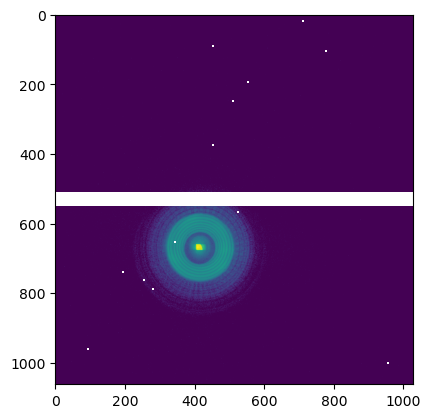

In [38]:
plt.imshow(np.log(dp_temp[0,:,:]+1))

In [39]:
for j in range(N_scan_dp):
     scipy.ndimage.interpolation.zoom(dp_temp[j+N_scan_x_lb,index_y_lb:index_y_ub,index_x_lb:index_x_ub],[resizeFactor,resizeFactor],dp[j,:,:], 1)

/tmp/ipykernel_13124/3758222837.py:2: DeprecationWarning: Please use `zoom` from the `scipy.ndimage` namespace, the `scipy.ndimage.interpolation` namespace is deprecated.
  scipy.ndimage.interpolation.zoom(dp_temp[j+N_scan_x_lb,index_y_lb:index_y_ub,index_x_lb:index_x_ub],[resizeFactor,resizeFactor],dp[j,:,:], 1)


In [40]:
# for j in range(N_scan_dp):
#     dp[j,:,:] = flipud(dp[j,:,:])

/tmp/ipykernel_13124/1220847106.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(dp[0,:,:]+1))


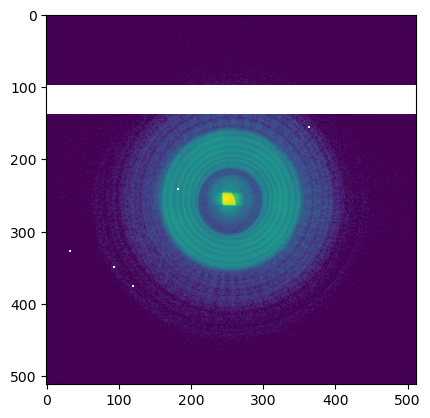

In [41]:
plt.imshow(np.log(dp[0,:,:]+1))

In [42]:
dp[dp<0] = 0
dp[dp>1e7] = 0

dp = dp[::resampleFactor,:,:]

##################### pad zeros to dp ##########################
if det_Npixel>N_dp_x_input: #currently only works for even size
    pad_before = (det_Npixel-N_dp_x_input)//2
    pad_after = (det_Npixel-N_dp_x_input)//2
    dp = np.pad(dp,((0,0),(pad_before,pad_after),(pad_before,pad_after)),'constant')

In [43]:
print("calculating scan positions")
ppx = -linspace(-floor(N_scan_x/2.0),ceil(N_scan_x/2.0)-1,N_scan_x)*scan_stepsize_x
ppy = linspace(-floor(N_scan_y/2.0),ceil(N_scan_y/2.0)-1,N_scan_y)*scan_stepsize_y
[ppX, ppY] = meshgrid(ppx,ppy)
# [ppY, ppX] = meshgrid(ppx,ppy)



calculating scan positions


In [18]:
ypos=np.array(mda_data[1].p[0].data)
xpos=np.array(mda_data[2].p[0].data)

print('y position shape:', ypos.shape)
print('x position shape:', xpos.shape)

y position shape: (41,)
x position shape: (41, 61)


In [19]:
ppX = -xpos*1e-6
ppY = np.repeat(ypos*1e-6,N_scan_y).reshape([N_scan_x,N_scan_y])
print('ppY shape:', ppY.shape)

ppY shape: (41, 61)


In [44]:
#shift positions to center around (0,0)
ppX = ppX - (np.max(ppX) + np.min(ppX))/2
ppY = ppY - (np.max(ppY) + np.min(ppY))/2
print(ppX.shape,ppY.shape)

(61, 61) (61, 61)


In [45]:
##################### resample dp ##########################
ppX = ppX[::resampleFactor]
ppY = ppY[::resampleFactor]

In [46]:
print(dp.shape,ppX.shape,ppY.shape)

(3721, 512, 512) (61, 61) (61, 61)


In [23]:
# dp = dp[41*1:,:,:]
# ppX = ppX[1:,:]
# ppY = ppY[1:,:]

In [47]:
print(dp.shape,ppX.shape,ppY.shape)

(3721, 512, 512) (61, 61) (61, 61)


In [48]:
##################### save data ##########################
print("saving " + 'data_roi' + roi + '.hdf5' + " to " + result_dir)
if not os.path.exists(result_dir): os.makedirs(result_dir)

dataName = 'data_roi' + roi + '_dp.hdf5'
f = h5py.File(result_dir + dataName, "w")
f.create_dataset("dp", shape=dp.shape,dtype='float64', data=dp, compression="gzip")
f.close()

f = h5py.File(result_dir + 'data_roi' + roi + '_para.hdf5', "w")
f.create_dataset("lambda", shape=(1,),dtype='float64', data=lam)
f.create_dataset("dx", shape=(1,),dtype='float64', data=dx)
f.create_dataset("ppY", shape=ppY.shape,dtype='float64', data=ppY)
f.create_dataset("ppX", shape=ppX.shape,dtype='float64', data=ppX)
f.close()

saving data_roi0_Ndp512.hdf5 to /mnt/data2/ssrf17u_20251026/test_target_stararea/test6_50nmstarresults/scan001/


In [49]:
dp.shape

(3721, 512, 512)

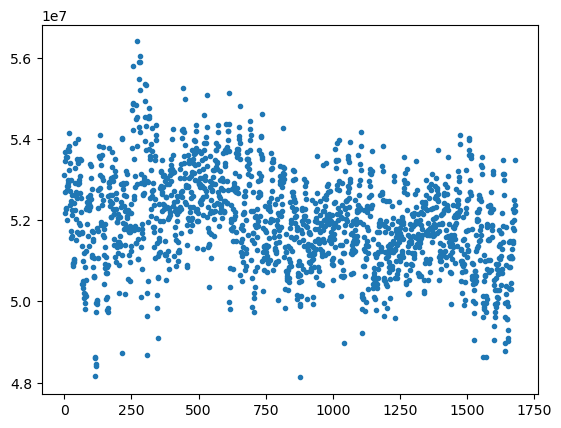

In [27]:
intensity = np.sum(dp, axis=(1,2))
plt.plot(intensity,'.')